In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(41)

In [ ]:
train_transforms = T.Compose([
    T.Resize((256,256)), # Standard ImageNet rescaling
    T.RandomCrop(224), # Random cropping (224x224)
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(), # Transforms the PIL image into Tensor (0.0 - 1.0)
    T.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[1.0, 1.0, 1.0]
    ),
])

val_transforms = T.Compose([
    T.Resize((256,256)),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[1.0, 1.0, 1.0]
    )
])

# Dataset Setup: Imagenette

**Imagenette** is a small vision dataset consisting of 10 easily classified classes extracted from the full ImageNet database (~144-150 GB). It is primarily used to quickly test new algorithm ideas before scaling up to larger datasets.

* **Included Classes:** tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute.
* **Source:** [fastai/imagenette GitHub Repository](https://github.com/fastai/imagenette)

---

## Dataset Splits & Statistics

The dataset uses a custom training and validation partition distribution.

### Training Split
$$N_{\text{train}} = 9,469 \text{ images}$$

### Validation Split
The validation set size is derived from the training set scaling factor:
$$N_{\text{val}} = 0.4145 \times N_{\text{train}}$$
$$N_{\text{val}} = 0.4145 \times 9,469 \approx 3,925 \text{ images}$$

---

## Environment & Dataset Preparation

Run the following shell commands directly in your notebook or terminal to download, extract, and structure the data directory.

```bash
# 1. Access your data directory and download the archive (~1.5GB)
mkdir -p data && cd data
wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz

# 2. Extract the downloaded tarball
tar -xf imagenette2.tgz

# 3. Restructure train and validation folders
mv imagenette2/train ./train
mv imagenette2/val ./val

# 4. Clean up the workspace by removing remnants
rm -rf imagenette2
rm imagenette2.tgz
```

In [ ]:
extract_dir='data'

In [ ]:
"""ImageFolder instances so that we know the location of both the train and validation splits and link the corresponding transformations"""
train_dataset = datasets.ImageFolder(root=os.path.join(extract_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(root=os.path.join(extract_dir, 'val'), transform=val_transforms)

In [ ]:
"""AlexNet standard batch size"""
BATCH_SIZE=16

In [ ]:
"""Instantiate the DataLoaders for both the train and val split"""
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

Feature batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


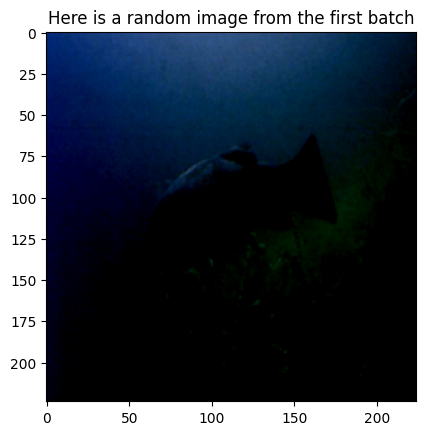

Label: 0


In [ ]:
"""Visualizing a random image from the imagenette dataset"""
rand_idx = torch.randint(0, BATCH_SIZE, (1,)).item() # Generates random numbers from 0 to BATCH_SIZE-1; the (1,) parameter basically indicates pytorch to return a tensor with a single element
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
print(train_features[0].shape)
print(train_features[0].squeeze().shape)
img = train_features[0].squeeze() # [B, H, W] -> [H, W]
img = img.permute(1, 2, 0) # [3, 224, 224] -> [224, 224, 3] | Matplotlib accepts just the Channels-Last format
label = train_labels[0]

plt.imshow(img, cmap='gray')
plt.title("Here is a random image from the first batch")
plt.show()
print(f"Label: {label}")

# Training loop breakdown
- Iterations per epoch: **9.469/16 (batch size) = ~592 steps**
- Total iterations: **74 x 30 (epochs) = 2.220**

In [ ]:
from src.model import AlexNet

model = AlexNet(num_classes=10) # Imagenette contains 10 labels
train_loss, val_loss, y_true, y_pred = model.fit(train_loader=train_loader, val_loader=val_loader, device='cuda', track=True, epochs=30)

AlexNet training will start on: CUDA
Epoch: 1 | Batch: 000 | Batch Loss: 2.3036
Epoch: 1 | Batch: 100 | Batch Loss: 2.3024
Epoch: 1 | Batch: 200 | Batch Loss: 2.3209
Epoch: 1 | Batch: 300 | Batch Loss: 2.2744
Epoch: 1 | Batch: 400 | Batch Loss: 2.2097
Epoch: 1 | Batch: 500 | Batch Loss: 2.4613
Epoch 01/30 completed | Train Loss: 2.2522 | Val Loss: 2.1627 | Val Acc: 22.96%
Epoch: 2 | Batch: 000 | Batch Loss: 2.2646
Epoch: 2 | Batch: 100 | Batch Loss: 2.3257
Epoch: 2 | Batch: 200 | Batch Loss: 2.0927
Epoch: 2 | Batch: 300 | Batch Loss: 1.9521
Epoch: 2 | Batch: 400 | Batch Loss: 1.5980
Epoch: 2 | Batch: 500 | Batch Loss: 1.7122
Epoch 02/30 completed | Train Loss: 2.0528 | Val Loss: 1.9338 | Val Acc: 30.85%
Epoch: 3 | Batch: 000 | Batch Loss: 1.9942
Epoch: 3 | Batch: 100 | Batch Loss: 1.9541
Epoch: 3 | Batch: 200 | Batch Loss: 1.9509
Epoch: 3 | Batch: 300 | Batch Loss: 1.7441
Epoch: 3 | Batch: 400 | Batch Loss: 1.6582
Epoch: 3 | Batch: 500 | Batch Loss: 1.4252
Epoch 03/30 completed | Train

In [ ]:
"""Save the model weights using the class method"""
model.save() # Creates a file named "alexnet_model.pth" that contains the state dictionary

AlexNet model saved to /content/AlexNet-from-scratch/src/alexnet_model.pth


## Let's now visualize the loss on both train and validation splits of **Imagenette** ##

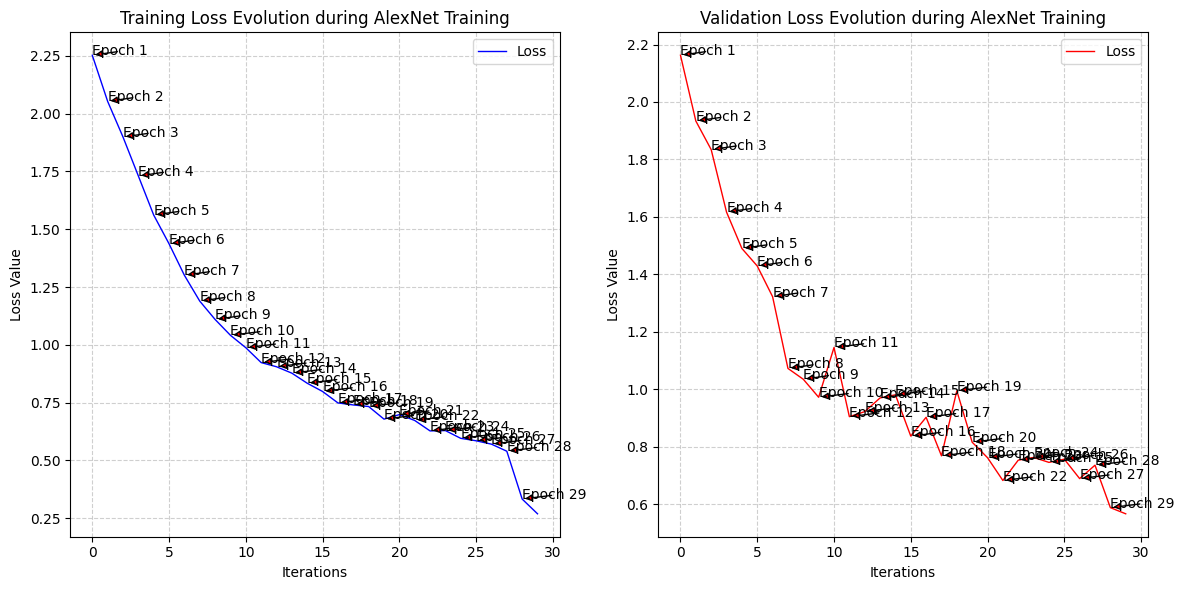

In [ ]:
"""Mostly boilerplate/boring matplotlib code"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

"""Plot training loss"""
ax1.plot(train_loss, label='Loss', color='blue', linewidth=1)

ax1.set_title("Training Loss Evolution during AlexNet Training")
ax1.set_xlabel("Iterations")
ax1.set_ylabel('Loss Value')
ax1.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 30): # 30 is the number of epochs we trained the AlexNet model for
    ax1.annotate(f'Epoch {i}', xy=(i-1, train_loss[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax1.legend()

"""Plot validation loss"""
ax2.plot(val_loss, label='Loss', color='red', linewidth=1)
ax2.set_title("Validation Loss Evolution during AlexNet Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 30):
    ax2.annotate(f'Epoch {i}', xy=(i-1, val_loss[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax2.legend()

plt.tight_layout()
plt.show()


# The Confusion Matrix

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_mat = confusion_matrix(y_true, y_pred)

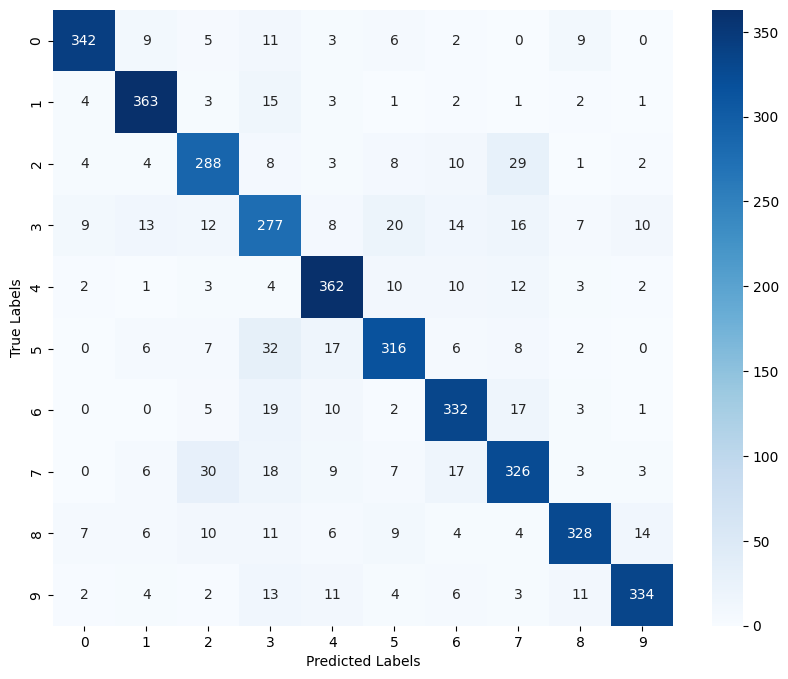

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

In [ ]:
cls_rep = classification_report(y_true, y_pred)

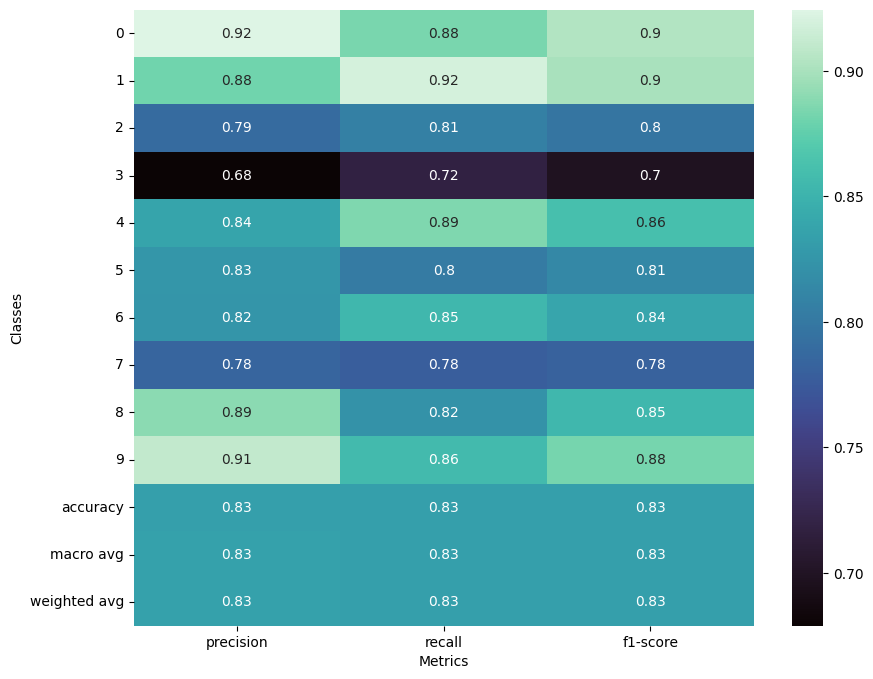

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).iloc[:-1, :].T, cmap='mako', annot=True)
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.show()

### **Model Performance Analysis on Outlier Label: Label 3 (Cassette Player)**
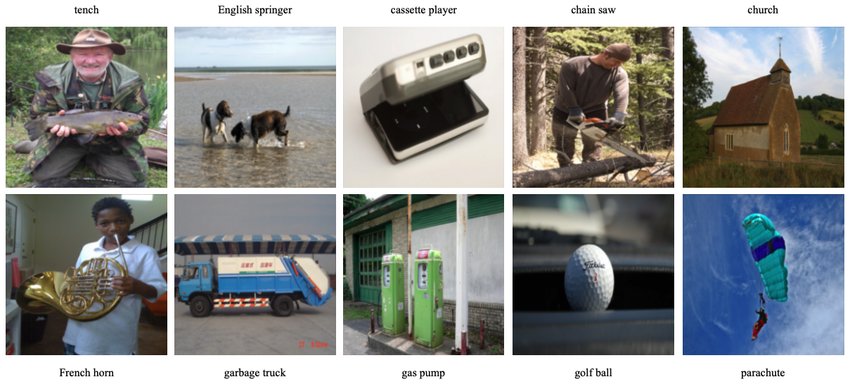

The model **struggled the most** with this category. Below is the breakdown of its metrics:

* **Precision (0.68):** **68%** of the predicted cassette player cases were correct.
* **Recall (0.72):** The model correctly identified **72%** of all actual cassette players.
* **F1-Score (0.70):** The balanced harmonic mean of precision and recall.

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = 0.70$$
